# Lab 4.1: Edge Detection

In this lab you will experiment with edge detection techniques.

In [49]:
!wget -nc -qq -O giraffe-portrait.jpg "https://www.dropbox.com/scl/fi/mzohe12b6absepe92ovq8/giraffe-portrait.jpg?rlkey=go4vawy9c7rwm1zk3lfc78vl1&dl=1"

We will work with an image of a circle to test our edge detector code, and afterward test the `giraffe-portrait.jpg` image.

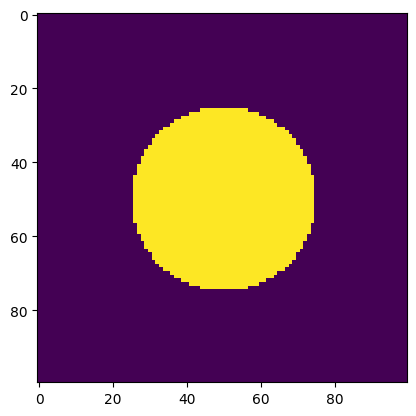

In [50]:
import cv2
import numpy as np
from skimage.draw import disk
from matplotlib import pyplot as plt

circle = np.zeros((100, 100))
r, c = disk((50, 50), 25)
circle[r, c] = 1

plt.imshow(circle)

# Exercises

1. Complete this function to compute the smoothed gradients $I_x=dI/dx$ and $I_y=dI/dy$:

- Gaussian blur the image (`skimage.filters.gaussian`) with the chosen $\sigma$ value
- Apply the derivative filters to compute $I_x$ and $I_y$
- Return $I_x$ and $I_y$

Test it on the circle image with sigma = 0 and sigma = 5 and show the results.

In [51]:
from skimage.filters import gaussian
from scipy.ndimage import correlate

def compute_gradient_images(image,sigma):
  # Gaussian blur the image (skimage.filters.gaussian) with the chosen σ value
  blured_image = gaussian(image, sigma)

  # Apply the derivative filters to compute Ix and Iy
  x_filter = np.array([[-1, 1]])
  y_filter = np.array([[-1],[1]])

  Ix = correlate(image, x_filter)
  Iy = correlate(image, y_filter)

  return Ix, Iy

2. Compute and show the gradient magnitude $\sqrt{I_x^2 + I_y^2}$ and gradient orientation $\tan^{-1}(I_y/I_x)$ images for sigma = 0 and sigma = 5.

*Note: use `np.atan2` to compute the gradient orientation.*

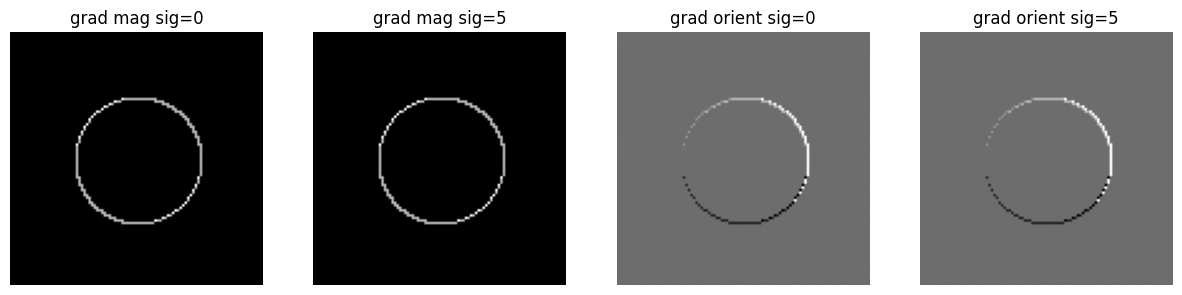

In [52]:
from numpy import atan2

def compute_gradient_magnitude(Ix, Iy):
  return pow((pow(Ix, 2) + pow(Iy, 2)), 0.5)

def compute_gradient_orientation(Ix, Iy):
  return atan2(Iy, Ix)

def fn_2():
  Ix0, Iy0 = compute_gradient_images(circle, 0)
  Ix5, Iy5 = compute_gradient_images(circle, 5)

  fig, (ax0, ax1, ax2, ax3) = plt.subplots(ncols=4, figsize=(15, 5))

  # Gradient Magnitude: Sigma = 0
  ax0.imshow(compute_gradient_magnitude(Ix0, Iy0), cmap='gray')
  ax0.set_title('grad mag sig=0')
  ax0.axis('off')

  # Gradient Magnitude: Sigma = 5
  ax1.imshow(compute_gradient_magnitude(Ix5, Iy5), cmap='gray')
  ax1.set_title('grad mag sig=5')
  ax1.axis('off')

  # Gradient Orientation: Sigma = 0
  ax2.imshow(compute_gradient_orientation(Ix0, Iy0), cmap='gray')
  ax2.set_title('grad orient sig=0')
  ax2.axis('off')

  # Gradient Orientation: Sigma = 5
  ax3.imshow(compute_gradient_orientation(Ix5, Iy5), cmap='gray')
  ax3.set_title('grad orient sig=5')
  ax3.axis('off')

fn_2()

3. Complete this function to compute oriented non-max suppresion and label the edge pixels.

- Compute the gradient magnitude image and add `1e-8` to ensure that we don't divide by zero in the next step.
- Divide $I_x$ and $I_y$ by the gradient magnitude image to normalize the gradient vectors.
- Use the `make_grid` function to make a grid of image coordinates $x$, $y$
- Use the `grid_sample` function to sample the neighbor values in the gradient magnitude image at $(x+I_x,y+I_y)$ and $(x-I_x,y-I_y)$
- Return a Boolean array which is true wherever the gradient magnitude is above the threshold and greater than the two neighbor values

Test the NMS function on the sigma=0 and sigma=5 data and analyze the results.

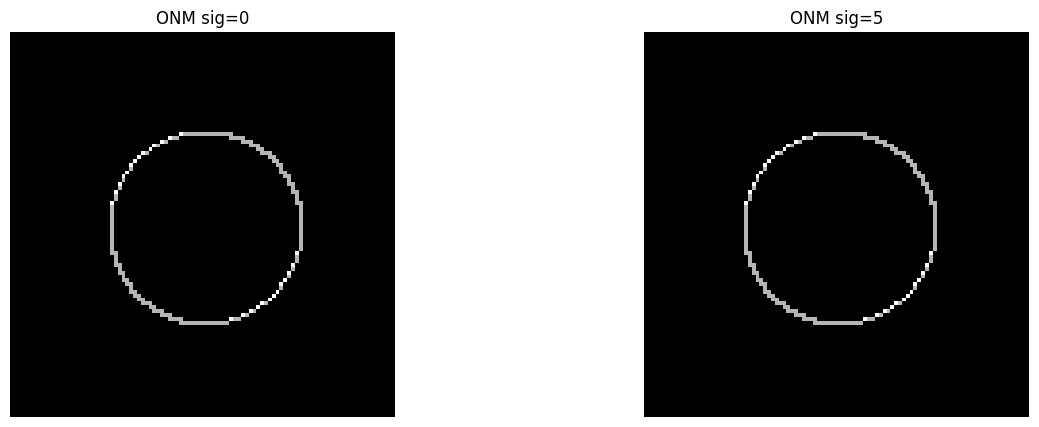

In [53]:
def make_grid(shape):
  y, x = np.meshgrid(np.arange(shape[0]), np.arange(shape[1]), indexing='ij')
  return x, y

def grid_sample(im,x,y):
  return cv2.remap(im, x.astype('float32'), y.astype('float32'), interpolation=cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT, borderValue=0)

def oriented_non_max(Ix, Iy, threshold=0.01):
  # Compute the gradient vectors
  grad_mag = compute_gradient_magnitude(Ix, Iy)

  # Add an epsilon to ensure we don't have division by 0 errors
  grad_mag = grad_mag+1e-8

  # Normalize gradient vectors
  Ix_normal = Ix/grad_mag
  Iy_normal = Iy/grad_mag

  # Make image grid based on the given shape
  x, y = make_grid(grad_mag.shape)

  # Sample neighbor values in gradient magnitude
  sample_plus = grid_sample(grad_mag, x+Ix_normal, y+Iy_normal)
  sample_minus = grid_sample(grad_mag, x-Ix_normal, y-Iy_normal)

  # Boolean mask for those pixels to keep
  mask = (grad_mag>threshold) & (grad_mag>=sample_minus) & (grad_mag>=sample_plus)
  nms = np.zeros_like(grad_mag)
  nms[mask] = grad_mag[mask]
  return nms

def fn_3():
  Ix0, Iy0 = compute_gradient_images(circle, 0)
  Ix5, Iy5 = compute_gradient_images(circle, 5)

  fig, (ax0, ax1) = plt.subplots(ncols=2, figsize=(15, 5))

  # Oriented Non Max: Sigma = 0
  ax0.imshow(oriented_non_max(Ix0, Iy0), cmap='gray')
  ax0.set_title('ONM sig=0')
  ax0.axis('off')

  # Oriented Non Max: Sigma = 5
  ax1.imshow(oriented_non_max(Ix5, Iy5), cmap='gray')
  ax1.set_title('ONM sig=5')
  ax1.axis('off')

fn_3()


RESPONSE: The edge detection seems to work just fine
with both sigma values. I think this might just be because we are working with such a simple geometry, but I think it might matter more when we load different images.

4. Now we will test on the `giraffe-portrait` image.

Hypothesize which edges in the image will detected with low and high levels of blur.

Try different settings of $\sigma$ from small to large.  Show the edge detection result for each sigma setting and analyze whether your hypotheses were correct.

In [54]:
from imageio.v3 import imread, imwrite
from skimage.color import rgb2gray

giraffe = imread('giraffe-portrait.jpg')
giraffe = giraffe.astype('float32')/255
giraffe_gray = rgb2gray(giraffe)

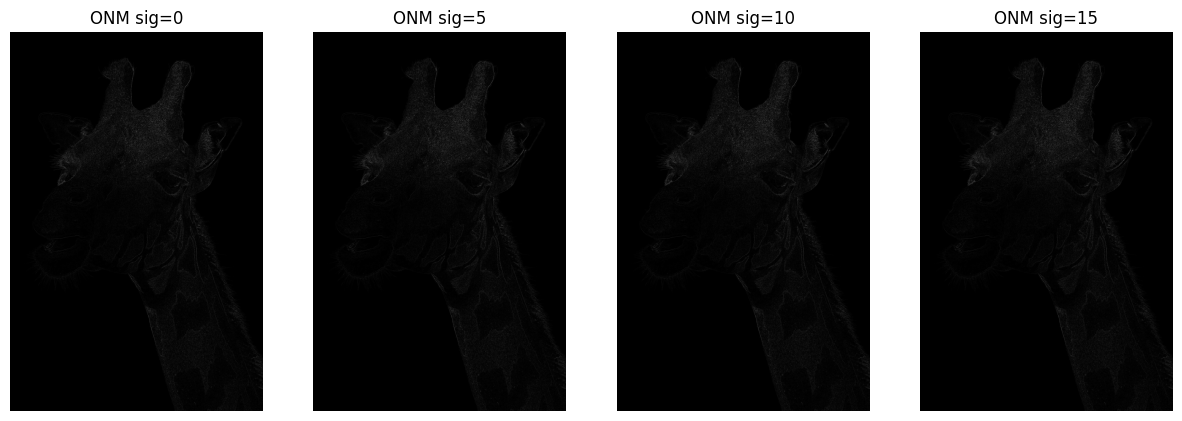

In [55]:
sigmas = [0, 5, 10, 15]

fig, axeses = plt.subplots(ncols=len(sigmas), figsize=(15, 5))

for i, sigma in enumerate(sigmas):
  Ix, Iy = compute_gradient_images(giraffe_gray, sigma)
  axis = axeses[i]

  axis.imshow(oriented_non_max(Ix, Iy), cmap='gray')
  axis.set_title(f'ONM sig={sigma}')
  axis.axis('off')


RESPONSE: My hypothesis is that the edges for the more blured image will result in smoother edge detection lines. I think the derivative will be less sharp, and thus the edge detector will have a "harder" time distinguishing the lines from each other.

What actually happened is that the sigma that affected the blur didn't really add anything to the clarity edge detection. It doesn't seem like there is any difference from the naked eye.

5. [optional] Once you have everything working, you can play around with this code to make a stylized rendering of the image!

In [56]:
from skimage.morphology import dilation, disk

# blur the color image
# blurred = gaussian(giraffe,sigma=7,channel_axis=-1)

# compute edges
# Ix, Iy = compute_gradient_images(giraffe_gray,sigma=7)
# nms = oriented_non_max(Ix,Iy,threshold=0.01)

# dilate edges
# nms = dilation(nms,footprint=disk(5))

# mark edge pixels as zero
# blurred[nms,:] = 0

# plt.imshow(blurred)
# imwrite('giraffe_stylized.jpg',(blurred*255).astype('uint8'))